## Imports

In [12]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture

## Task 1

### Reading the Data (Copied from the first Exercise)

In [13]:
# Reading in the data and subsequentially cutting out a redshift range and diving between red and blue galaxies according to color.
data = pandas.read_csv('../sdss_cutout.csv')
z = data['Z'].values
# Changed to a thinner slice
z_mask_thin = (z > 0.095) & (z < 0.105)
z_mask_full = (z > 0.08) & (z < 0.12)
data_thin = data[z_mask_thin].reset_index(drop=True)
data_full = data[z_mask_full].reset_index(drop=True)

ra_thin = data_thin['RA'].values
dec_thin = data_thin['DEC'].values

ra_full = data_full['RA'].values
dec_full = data_full['DEC'].values

# Computing the color of the galaxies and dividing them into red and blue populations according to the color cut at 2.3.
u_mag = data_thin['phot_u'].values
r_mag = data_thin['phot_r'].values
color = u_mag - r_mag
red_gal = data_thin[color > 2.3].reset_index(drop=True)
blue_gal = data_thin[color <= 2.3].reset_index(drop=True)

# Reading out the RA and DEC values from the two populations.
red_gal_ra = red_gal['RA'].values
red_gal_dec = red_gal['DEC'].values

blue_gal_ra = blue_gal['RA'].values
blue_gal_dec = blue_gal['DEC'].values

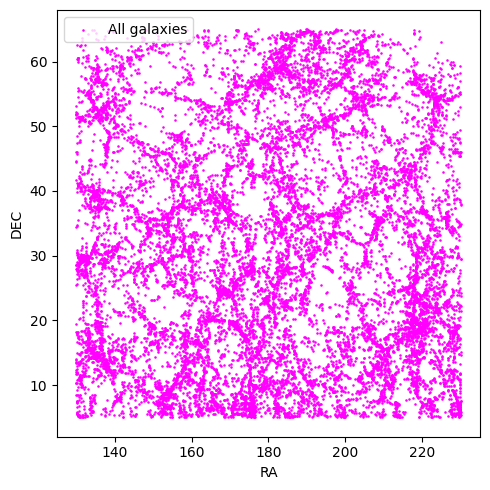

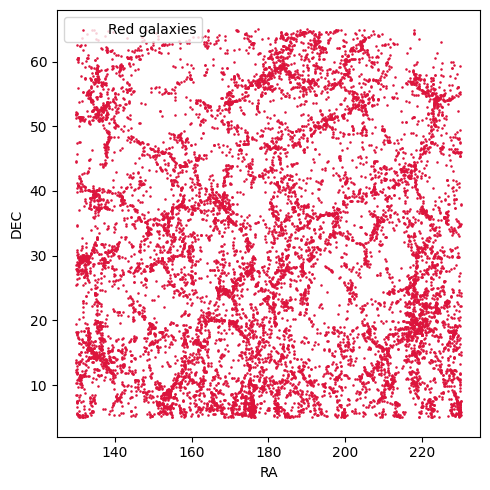

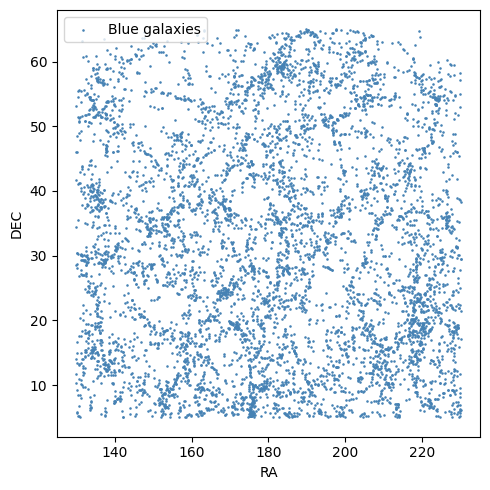

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(ra_thin, dec_thin, s=0.7, color='magenta', label='All galaxies')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(red_gal_ra, red_gal_dec, s=0.7, color='crimson', label='Red galaxies')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(blue_gal_ra, blue_gal_dec, s=0.7, color='steelblue', label='Blue galaxies')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.legend()
plt.tight_layout()
plt.show()

## Task 2

In [15]:
Xgrid = np.column_stack([ra_thin, dec_thin])


bandwidths = np.geomspace(0.05, 2.0, 30)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
    {'bandwidth': bandwidths}, cv=LeaveOneOut(), n_jobs=-1)
grid.fit(Xgrid) # Xdata has shape (N,2) for 2D

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KernelDensity()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bandwidth': array([0.05 ..., 2. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate 

In [16]:
h_opt = grid.best_params_['bandwidth']
print(f'Optimal bandwidth: {h_opt:.3f}')

sigma_hat  = np.sqrt(np.std(ra_thin) * np.std(dec_thin))   # geometric mean
h_silverman = 1.06 * sigma_hat * len(Xgrid)**(-1/5)

print(f'Silverman bandwidth: {h_silverman:.3f}')

cv_scores  = grid.cv_results_['mean_test_score']
cv_std     = grid.cv_results_['std_test_score']

Optimal bandwidth: 0.297
Silverman bandwidth: 3.239


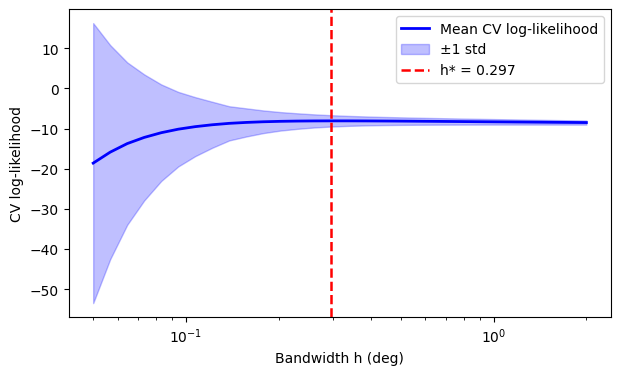

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(bandwidths, cv_scores, 'b-', lw=2, label='Mean CV log-likelihood')
ax.fill_between(bandwidths, cv_scores-cv_std, cv_scores+cv_std,
                alpha=0.25, color='blue', label='±1 std')
ax.axvline(h_opt,        color='red',        ls='--', lw=1.8, label=f'h* = {h_opt:.3f}')
#ax.axvline(h_silverman,  color='darkorange', ls='--', lw=1.8, label=f'h_Silv = {h_silverman:.3f}')
ax.set_xlabel("Bandwidth h (deg)"); ax.set_ylabel("CV log-likelihood")
ax.legend()
#ax.set_title("Task 2: 5-fold CV score vs. bandwidth"); ax.legend(fontsize=9)

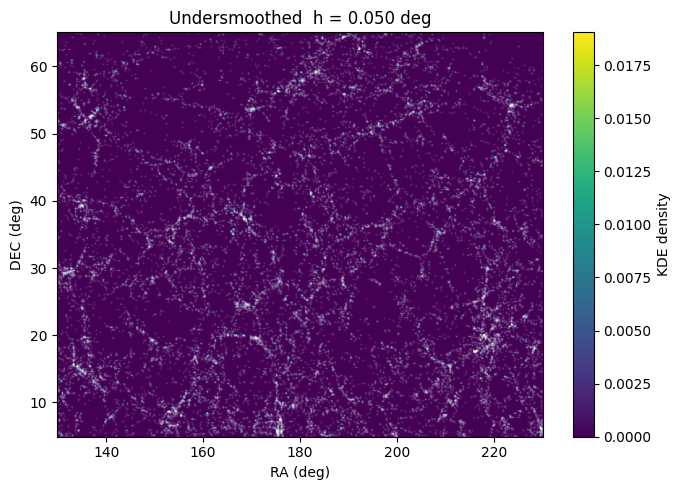

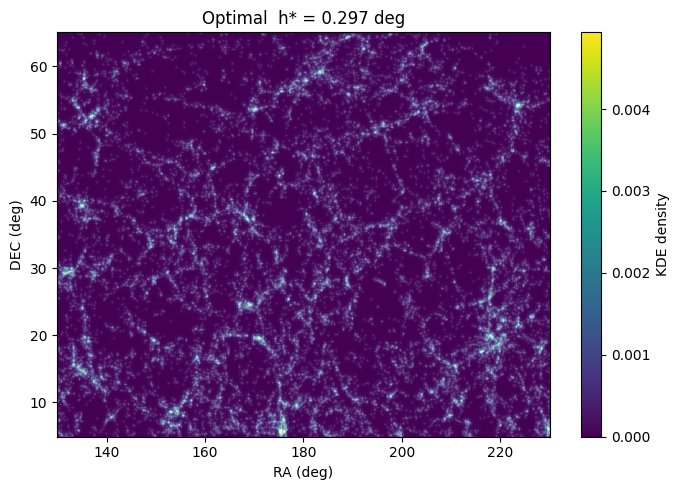

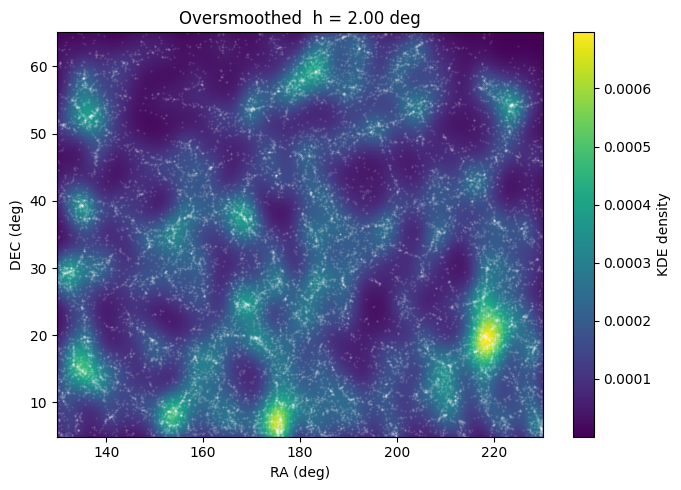

In [18]:
# --- Task 2: Three 2D density maps (undersmoothed, optimal h*, oversmoothed) ---

h_under = bandwidths[0]    # undersmoothed: smallest bandwidth in grid (0.05 deg)
h_over  = bandwidths[-1]   # oversmoothed:  largest bandwidth in grid (2.0 deg)

# Build a 2D evaluation grid covering the RA/DEC extent of the data
n_grid = 300
ra_grid  = np.linspace(ra_thin.min(),  ra_thin.max(),  n_grid)
dec_grid = np.linspace(dec_thin.min(), dec_thin.max(), n_grid)
RA_mesh, DEC_mesh = np.meshgrid(ra_grid, dec_grid)
eval_pts = np.column_stack([RA_mesh.ravel(), DEC_mesh.ravel()])

def eval_kde_2d(h, X_train, eval_pts, grid_shape):
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X_train)
    return np.exp(kde.score_samples(eval_pts)).reshape(grid_shape)

dens_under = eval_kde_2d(h_under, Xgrid, eval_pts, RA_mesh.shape)
dens_opt   = eval_kde_2d(h_opt,   Xgrid, eval_pts, RA_mesh.shape)
dens_over  = eval_kde_2d(h_over,  Xgrid, eval_pts, RA_mesh.shape)

configs = [
    (dens_under, f'Undersmoothed  h = {h_under:.3f} deg'),
    (dens_opt,   f'Optimal  h* = {h_opt:.3f} deg'),
    (dens_over,  f'Oversmoothed  h = {h_over:.2f} deg'),
]
for Z, title in configs:
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.pcolormesh(RA_mesh, DEC_mesh, Z, shading='auto')
    ax.scatter(ra_thin, dec_thin, s=0.2, color='white', alpha=0.15)
    ax.set_xlabel('RA (deg)')
    ax.set_ylabel('DEC (deg)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='KDE density')
    plt.tight_layout()
    plt.show()


## Task 3

In [19]:
u_mag = data_thin['phot_u'].values
r_mag = data_thin['phot_r'].values
color = u_mag - r_mag

bic_scores = []
for k in range(1, 7):
    gm = GaussianMixture(n_components=k, n_init=20).fit(color[:,np.newaxis])
    bic_scores.append(gm.bic(color[:,np.newaxis]))

BIC scores: ['K=1:28759', 'K=2:24665', 'K=3:24816', 'K=4:22447', 'K=5:22498', 'K=6:22541']
DELTA_BIC: ['K=2:4093', 'K=3:-151', 'K=4:2369', 'K=5:-51', 'K=6:-43']


Text(0, 0.5, 'BIC score')

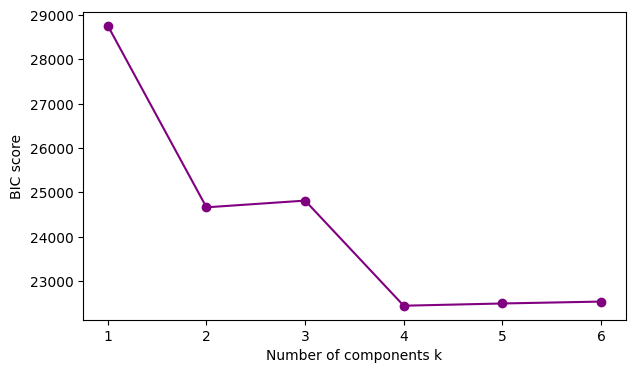

In [20]:
delta_bic = [bic_scores[k-1] - bic_scores[k] for k in range(1, 6)]
print("BIC scores:", [f"K={k}:{b:.0f}" for k,b in enumerate(bic_scores,1)])
print("DELTA_BIC:", [f"K={k}:{d:.0f}" for k,d in enumerate(delta_bic,2)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 7), bic_scores, 'o-', color='purple')
ax.set_xlabel("Number of components k"); ax.set_ylabel("BIC score")

GMM component means:   [1.83743431 2.3114239  2.85264997]
GMM component weights: [0.25247781 0.17701527 0.57050692]
Reddest component index: 0  (mean u-r = 2.853)


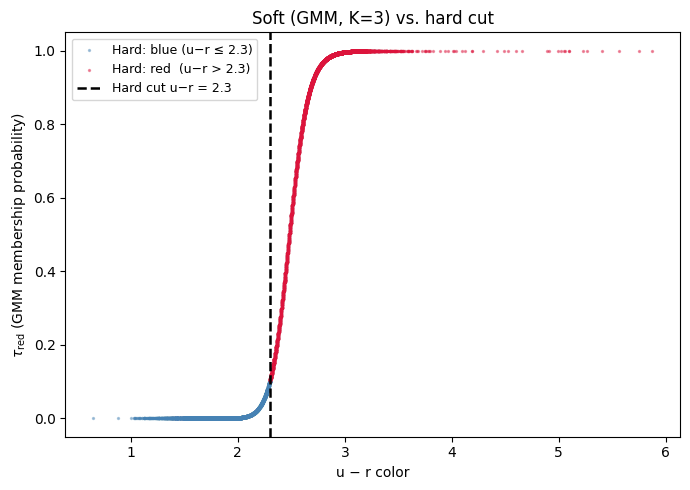

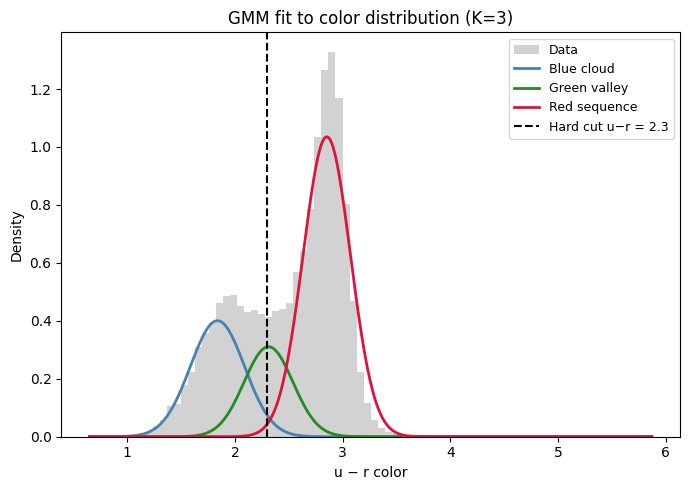

In [21]:
N_comp = 3
gm_chosen = GaussianMixture(n_components=N_comp, n_init=20).fit(color[:, np.newaxis])
tau = gm_chosen.predict_proba(color[:, np.newaxis])   # shape (N_galaxies, N_comp)

# Identify the reddest component by its mean color
comp_means = gm_chosen.means_.flatten()
red_idx  = np.argmax(comp_means)
blue_idx = np.argmin(comp_means)
tau_red  = tau[:, red_idx]

print(f"GMM component means:   {np.sort(comp_means)}")
print(f"GMM component weights: {gm_chosen.weights_[np.argsort(comp_means)]}")
print(f"Reddest component index: {red_idx}  (mean u-r = {comp_means[red_idx]:.3f})")

# Hard cut from worksheet 1
hard_red = color > 2.3

# ---- Plot 1: scatter of u-r color vs tau_red ----
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(color[~hard_red], tau_red[~hard_red], s=2, alpha=0.4,
           color='steelblue', label='Hard: blue (u−r ≤ 2.3)')
ax.scatter(color[hard_red],  tau_red[hard_red],  s=2, alpha=0.4,
           color='crimson',   label='Hard: red  (u−r > 2.3)')
ax.axvline(2.3, color='black', ls='--', lw=1.8, label='Hard cut u−r = 2.3')
ax.set_xlabel('u − r color')
ax.set_ylabel(r'$\tau_\mathrm{red}$ (GMM membership probability)')
ax.set_title(f'Soft (GMM, K={N_comp}) vs. hard cut')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ---- Plot 2: color histogram + individual GMM components ----
c_range = np.linspace(color.min(), color.max(), 400)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(color, bins=80, density=True, alpha=0.35, color='gray', label='Data')

weights = gm_chosen.weights_
stds    = np.sqrt(gm_chosen.covariances_.flatten())
sort_order = np.argsort(comp_means)          # blue → green → red
palette = ['steelblue', 'forestgreen', 'crimson']
comp_labels = ['Blue cloud', 'Green valley', 'Red sequence']

for plot_idx, j in enumerate(sort_order):
    pdf_j = (weights[j]
             * np.exp(-0.5 * ((c_range - comp_means[j]) / stds[j])**2)
             / (stds[j] * np.sqrt(2 * np.pi)))
    ax.plot(c_range, pdf_j, lw=2,
            color=palette[plot_idx], label=comp_labels[plot_idx])

ax.axvline(2.3, color='black', ls='--', lw=1.5, label='Hard cut u−r = 2.3')
ax.set_xlabel('u − r color')
ax.set_ylabel('Density')
ax.set_title(f'GMM fit to color distribution (K={N_comp})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
